In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/reusable_codes')

from euler import euler


Mounted at /content/drive


## GROUP 13 Lab 07

Members :
   
Khushi Shah - 202401471

Tanish Sanghavi - 202401465

Sharvil Shah - 202401196


# PROBLEM 2
## Forced Undamped Harmonic Oscillator

We study the second-order ODE:

$$
\ddot{x} + x = \cos(\omega t), \qquad x(0) = 0,\quad \dot{x}(0) = 0
$$

Here the **natural frequency** of the undriven oscillator is $\omega_0 = 1$ rad/s (since the coefficient of $x$ is 1).

### Analytical Solution

This is a linear ODE with constant coefficients. The general solution is the sum of the homogeneous solution and a particular solution.

**Case 1 — Non-resonant ($\omega \neq \omega_0 = 1$):**

The particular solution has the form $x_p = A\cos(\omega t)$. Substituting:

$$
-A\omega^2\cos(\omega t) + A\cos(\omega t) = \cos(\omega t)
\implies A = \frac{1}{1 - \omega^2}
$$

Applying the initial conditions $x(0) = 0,\ \dot{x}(0) = 0$, the full solution is:

$$
\boxed{x(t) = \frac{\cos(\omega t) - \cos(t)}{1 - \omega^2}}, \qquad \omega \neq 1
$$

This can be rewritten using the sum-to-product identity:

$$
x(t) = \frac{2}{1-\omega^2}\,\sin\!\left(\frac{1+\omega}{2}t\right)\sin\!\left(\frac{1-\omega}{2}t\right)
$$

When $\omega$ is close to 1, the factor $\sin\!\left(\frac{1-\omega}{2}t\right)$ oscillates slowly — this produces the **beating** phenomenon.

**Case 2 — Resonance ($\omega = \omega_0 = 1$):**

The homogeneous and particular frequencies coincide, so we apply L'Hôpital's rule to the non-resonant solution (or solve directly using the method of variation of parameters):

$$
\lim_{\omega \to 1} \frac{\cos(\omega t) - \cos(t)}{1-\omega^2} = \frac{t\sin(t)}{2}
$$

$$
\boxed{x(t) = \frac{t}{2}\sin(t)}, \qquad \omega = 1
$$

The amplitude grows **linearly** with time — this is pure resonance. In a physical system with no damping, the oscillator absorbs energy indefinitely from the driving force, leading to unbounded growth.


## Analytical Solution Function

We implement the exact analytical solution for both the resonant and non-resonant cases.


In [3]:
# Time array: 0 to 20π
t = np.linspace(0, 20 * np.pi, 2000)

def x_analytical(t, w):
    """
    Analytical solution of x'' + x = cos(wt), x(0)=0, x'(0)=0.
    Uses L'Hopital limit at resonance (w = 1).
    """
    if abs(w - 1) < 1e-5:        # resonance: amplitude grows as t/2 * sin(t)
        return (t / 2) * np.sin(t)
    else:                         # non-resonant: beating pattern
        return (np.cos(w * t) - np.cos(t)) / (1 - w**2)


## Plotting $x(t)$ for Three Values of $\omega$

We compare the oscillator response for:

| Case | $\omega$ | Description |
|------|-----------|-------------|
| 1 | $\omega = 0.5$ | Small — well below natural frequency |
| 2 | $\omega = 1.0$ | Equal to $\omega_0$ — **resonance** |
| 3 | $\omega = 2.0$ | Large — well above natural frequency |

All plots run from $t = 0$ to $t = 20\pi \approx 62.8$ s.


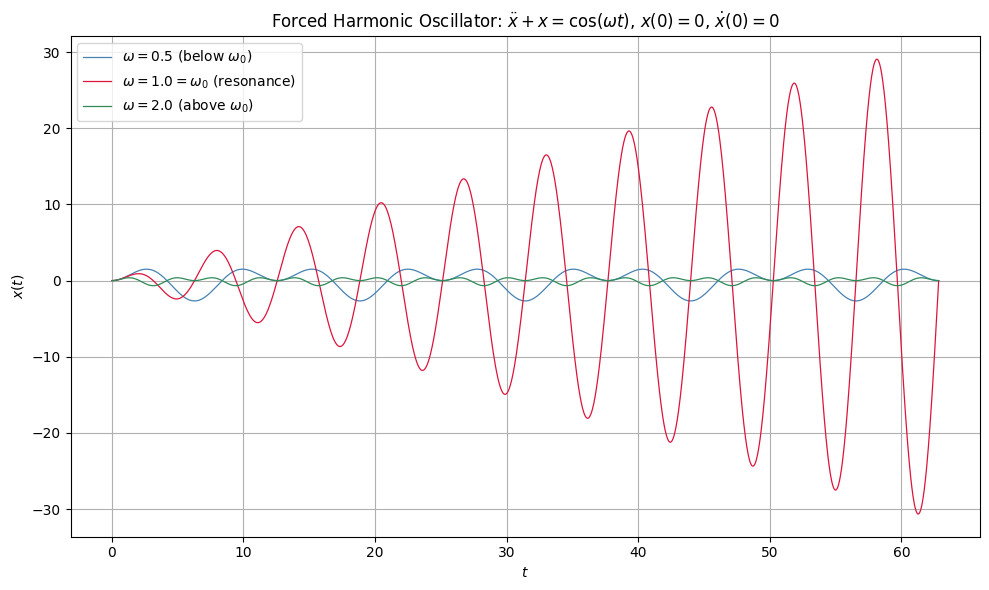

In [4]:
# Three driving frequencies: below, at, and above natural frequency
omegas = [0.5, 1.0, 2.0]
colors  = ['steelblue', 'crimson', 'seagreen']
labels  = [r'$\omega = 0.5$ (below $\omega_0$)',
           r'$\omega = 1.0 = \omega_0$ (resonance)',
           r'$\omega = 2.0$ (above $\omega_0$)']

plt.figure(figsize=(10, 6))

for w, col, lbl in zip(omegas, colors, labels):
    plt.plot(t, x_analytical(t, w), color=col, linewidth=0.9, label=lbl)

plt.xlabel(r'$t$')
plt.ylabel(r'$x(t)$')
plt.title(r'Forced Harmonic Oscillator: $\ddot{x} + x = \cos(\omega t)$, $x(0)=0$, $\dot{x}(0)=0$')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


## Observations and Theoretical Explanation

### $\omega = 0.5$ — Below Natural Frequency

The solution $x(t) = \dfrac{\cos(0.5\,t) - \cos(t)}{1 - 0.25}$ is a superposition of two cosines with frequencies 0.5 and 1. The result is a **beating** pattern: a fast oscillation at the average frequency $\frac{1+0.5}{2} = 0.75$ rad/s modulated by a slow envelope oscillating at $\frac{1-0.5}{2} = 0.25$ rad/s. The amplitude remains **bounded**.

$$
x(t) = \frac{2}{0.75}\sin(0.75\,t)\sin(0.25\,t)
$$

### $\omega = 1.0$ — Resonance ($\omega = \omega_0$)

At resonance the solution is $x(t) = \dfrac{t}{2}\sin(t)$. The amplitude grows **linearly without bound** as $t \to \infty$. This is because at every cycle the driving force does positive net work on the oscillator — energy accumulates with no damping mechanism to remove it. In physical systems, damping limits this growth, but here the ideal undamped oscillator exhibits runaway growth.

### $\omega = 2.0$ — Above Natural Frequency

The solution $x(t) = \dfrac{\cos(2t) - \cos(t)}{1 - 4} = \dfrac{\cos(2t) - \cos(t)}{-3}$ is again bounded. The amplitude is smaller than the $\omega = 0.5$ case because the factor $|1/(1-\omega^2)| = 1/3$ is smaller than $1/(1-0.25) = 4/3$. The oscillation is a beat between frequencies 1 and 2 rad/s.

### General Trend with Increasing $\omega$

- For $\omega \ll 1$: the amplitude envelope $\approx \dfrac{2}{1-\omega^2}$ is slightly above 2; the beating period is very long.
- As $\omega \to 1^-$: the amplitude grows without bound — the resonance divergence.
- At $\omega = 1$: unbounded linear growth $\sim t/2$.
- As $\omega \to 1^+$: amplitude again diverges, then falls.
- For $\omega \gg 1$: the amplitude $\approx 1/\omega^2 \to 0$; the system cannot follow the rapidly varying force.


## Conclusion

We solved the forced undamped harmonic oscillator $\ddot{x} + x = \cos(\omega t)$ analytically and plotted the response for three driving frequencies.

- For **$\omega = 0.5$** and **$\omega = 2.0$** (off-resonance): the solution is a bounded beating oscillation, a superposition of two frequencies. The amplitude of the envelope is controlled by $|1/(1-\omega^2)|$.

- For **$\omega = 1.0 = \omega_0$** (resonance): the amplitude grows linearly with time as $t\sin(t)/2$, demonstrating that an undamped oscillator driven exactly at its natural frequency absorbs energy indefinitely.

- As $\omega$ increases from small to large, the system transitions from large-amplitude beating through the resonance catastrophe and finally to small-amplitude, high-frequency oscillations that the system is too slow to follow.
